# Model Recovery Analysis

This notebook analyzes the results of the model recovery experiment, where different models are used to generate synthetic data and then all models are fit to that data to see which model best recovers the true generating model.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from popy.config import PROJECT_PATH_LOCAL

## Load Results

In [2]:
# Load the model recovery results
results_path = os.path.join(PROJECT_PATH_LOCAL, "notebooks", "behav_modeling", "results", "model_recovery_foraging.csv")
df = pd.read_csv(results_path)

print(f"Loaded {len(df)} simulations")
df

Loaded 72 simulations


,model_true,model_fitted,iteration,LPT_best,alpha,beta,stickyness_bias,V0
0,Repeating agent,Repeating agent,0,0.999933,NaN,NaN,NaN,NaN
1,Repeating agent,Standard RL,0,0.998755,NaN,NaN,NaN,NaN
2,Repeating agent,Standard RL - stickyness,0,0.998902,NaN,NaN,NaN,NaN
3,Repeating agent,Inferential RL,0,0.333058,NaN,NaN,NaN,NaN
4,Repeating agent,Inferential RL - stickyness,0,0.996758,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
67,Foraging,Standard RL,1,0.496787,0.14402,19.101686,NaN,0.46606
68,Foraging,Standard RL - stickyness,1,0.493687,0.14402,19.101686,NaN,0.46606
69,Foraging,Inferential RL,1,0.516830,0.14402,19.101686,NaN,0.46606
70,Foraging,Inferential RL - stickyness,1,0.511864,0.14402,19.101686,NaN,0.46606


## Confusion Matrix: Mean LPT per Model Pair

The confusion matrix shows the mean log posterior (LPT) for each combination of true model (y-axis) and fitted model (x-axis). Higher values indicate better fits. Ideally, the diagonal should have the highest values, indicating each model is best identified by itself.

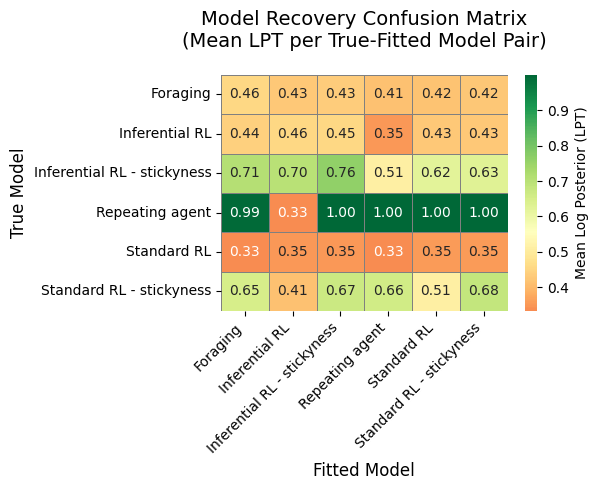


Confusion Matrix:
model_fitted                 Foraging  Inferential RL   
model_true                                              
Foraging                     0.455465        0.428250  \
Inferential RL               0.440077        0.456741   
Inferential RL - stickyness  0.705783        0.697785   
Repeating agent              0.993692        0.332943   
Standard RL                  0.332567        0.352937   
Standard RL - stickyness     0.645660        0.413840   

model_fitted                 Inferential RL - stickyness  Repeating agent   
model_true                                                                  
Foraging                                        0.433065         0.412289  \
Inferential RL                                  0.452968         0.351601   
Inferential RL - stickyness                     0.761066         0.511135   
Repeating agent                                 0.997757         0.999929   
Standard RL                                     0.353123      

In [3]:
# Create pivot table with mean LPT for each true-fitted model pair
confusion_matrix = df.pivot_table(
    values='LPT_best',
    index='model_true',
    columns='model_fitted',
    aggfunc='mean'
)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=confusion_matrix.values.mean(),
    cbar_kws={'label': 'Mean Log Posterior (LPT)'},
    linewidths=0.5,
    linecolor='gray'
)
plt.title('Model Recovery Confusion Matrix\n(Mean LPT per True-Fitted Model Pair)', fontsize=14, pad=20)
plt.xlabel('Fitted Model', fontsize=12)
plt.ylabel('True Model', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix:")
print(confusion_matrix)